# 01. EDA временного ряда энергопотребления

В первом ноутбуке выполнена загрузка данных, приведение таблицы к формату временного ряда, проверка качества данных, анализ сезонности и стационарности. Также зафиксирована постановка задачи прогнозирования и сохранен подготовленный датасет для следующих этапов.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## Загрузка данных

In [2]:
path = "../data/raw/de_hourly_power_and_weather.csv"
df = pd.read_csv(path)
df.head()

,utc_timestamp,Consumption,Wind,Solar,Wind+Solar,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
0,2015-01-01 00:00:00+00:00,41.151,8.852,NaN,NaN,-0.981,0.0,0.0
1,2015-01-01 01:00:00+00:00,40.135,9.054,NaN,NaN,-1.035,0.0,0.0
2,2015-01-01 02:00:00+00:00,39.106,9.070,NaN,NaN,-1.109,0.0,0.0
3,2015-01-01 03:00:00+00:00,38.765,9.163,NaN,NaN,-1.166,0.0,0.0
4,2015-01-01 04:00:00+00:00,38.941,9.231,NaN,NaN,-1.226,0.0,0.0


## Постановка задачи

В работе исследуется почасовой временной ряд энергопотребления за 2015-2019 годы с погодными и энергетическими признаками.

- Колонка времени: `utc_timestamp`
- Целевая переменная для прогноза: `Consumption`
- Горизонт прогноза: 24 часа вперед
- Сценарий: offline-прогнозирование по историческим данным
- Метрики качества: MAE, RMSE, SMAPE
- Погодные признаки: `temperature`, `radiation_direct_horizontal`, `radiation_diffuse_horizontal`
- Дополнительные энергетические признаки: `Wind`, `Solar`, `Wind+Solar`

На этапе EDA проверены качество временной шкалы, пропуски, сезонные паттерны, связь целевой переменной с признаками и свойства ряда для дальнейшего моделирования.

In [3]:
time_col = "utc_timestamp"
target_col = "Consumption"
weather_features = [
    "temperature",
    "radiation_direct_horizontal",
    "radiation_diffuse_horizontal",
]
energy_features = ["Wind", "Solar", "Wind+Solar"]

df[time_col] = pd.to_datetime(df[time_col], utc=True)
df = df.sort_values(time_col).set_index(time_col)
df.index.name = "timestamp"

df.head()

,Consumption,Wind,Solar,Wind+Solar,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
timestamp,,,,,,,
2015-01-01 00:00:00+00:00,41.151,8.852,NaN,NaN,-0.981,0.0,0.0
2015-01-01 01:00:00+00:00,40.135,9.054,NaN,NaN,-1.035,0.0,0.0
2015-01-01 02:00:00+00:00,39.106,9.070,NaN,NaN,-1.109,0.0,0.0
2015-01-01 03:00:00+00:00,38.765,9.163,NaN,NaN,-1.166,0.0,0.0
2015-01-01 04:00:00+00:00,38.941,9.231,NaN,NaN,-1.226,0.0,0.0


## Протокол прогнозирования

Для сравнения моделей используется единый протокол. Он фиксирует горизонт прогноза, train/test split и набор метрик, чтобы результаты статистических, ML и DL-моделей были сопоставимы.

In [4]:
forecast_horizon = 24
metrics = ["MAE", "RMSE", "SMAPE"]
test_start = "2019-01-01"

train_df = df.loc[df.index < test_start].copy()
test_df = df.loc[df.index >= test_start].copy()

print("Горизонт прогноза, часов:", forecast_horizon)
print("Метрики:", metrics)
print("Train:", train_df.index.min(), "->", train_df.index.max(), train_df.shape)
print("Test:", test_df.index.min(), "->", test_df.index.max(), test_df.shape)

Горизонт прогноза, часов: 24
Метрики: ['MAE', 'RMSE', 'SMAPE']
Train: 2015-01-01 00:00:00+00:00 -> 2018-12-31 23:00:00+00:00 (35064, 7)
Test: 2019-01-01 00:00:00+00:00 -> 2019-12-31 23:00:00+00:00 (8760, 7)


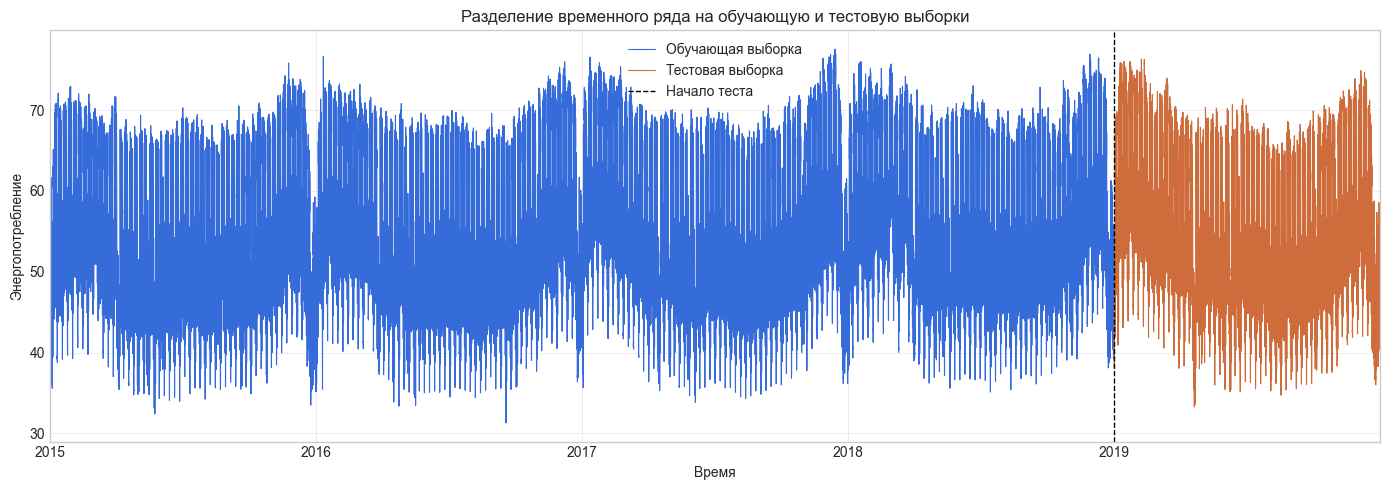

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
train_df[target_col].plot(ax=ax, label="Обучающая выборка", linewidth=0.8)
test_df[target_col].plot(ax=ax, label="Тестовая выборка", linewidth=0.8)
ax.axvline(pd.Timestamp(test_start, tz="UTC"), color="black", linestyle="--", linewidth=1, label="Начало теста")
ax.set_title("Разделение временного ряда на обучающую и тестовую выборки")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление")
ax.legend()
plt.tight_layout()

Выбран holdout по последнему году: 2015-2018 годы используются для обучения, 2019 год для финальной проверки. Такой split сохраняет временной порядок и не допускает утечки будущих наблюдений в обучение.

## Базовые проверки

In [6]:
print("Размер данных:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

print("\nДиапазон времени:", df.index.min(), "->", df.index.max())
print("Дубликаты временных меток:", df.index.duplicated().sum())
print("Индекс отсортирован по возрастанию:", df.index.is_monotonic_increasing)

freq_check = df.index.to_series().diff().value_counts().head()
print("\nНаиболее частые интервалы между наблюдениями:")
print(freq_check)

Размер данных: (43824, 7)

Типы данных:
Consumption                     float64
Wind                            float64
Solar                           float64
Wind+Solar                      float64
temperature                     float64
radiation_direct_horizontal     float64
radiation_diffuse_horizontal    float64
dtype: object

Диапазон времени: 2015-01-01 00:00:00+00:00 -> 2019-12-31 23:00:00+00:00
Дубликаты временных меток: 0
Индекс отсортирован по возрастанию: True

Наиболее частые интервалы между наблюдениями:
timestamp
0 days 01:00:00    43823
Name: count, dtype: int64


In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": (df.isna().mean() * 100).round(3),
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_ratio
Wind+Solar,105,0.240
Solar,103,0.235
Wind,74,0.169
Consumption,0,0.000
temperature,0,0.000
radiation_direct_horizontal,0,0.000
radiation_diffuse_horizontal,0,0.000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Consumption,43824.0,55.859295,10.005620,31.307,47.43200,55.4670,64.788250,77.5490
Wind,43750.0,11.157555,8.694138,0.135,4.42225,8.7280,15.584000,45.0850
Solar,43721.0,4.304566,6.603858,0.000,0.00000,0.1260,6.822000,30.0280
Wind+Solar,43719.0,15.463925,9.936818,0.312,7.34900,13.6550,22.091500,55.2430
temperature,43824.0,9.850719,8.130236,-12.686,3.26100,9.2375,16.027000,35.4790
radiation_direct_horizontal,43824.0,82.750879,158.999319,0.000,0.00000,0.4222,79.198375,841.6810
radiation_diffuse_horizontal,43824.0,67.073695,89.173985,0.000,0.00000,6.3222,119.514000,392.0895


В этом блоке выполнена проверка непрерывности временной шкалы, пропусков в целевой переменной и состояния дополнительных признаков. Эти проверки нужны для корректной подготовки данных перед моделированием.

## Анализ целевой переменной

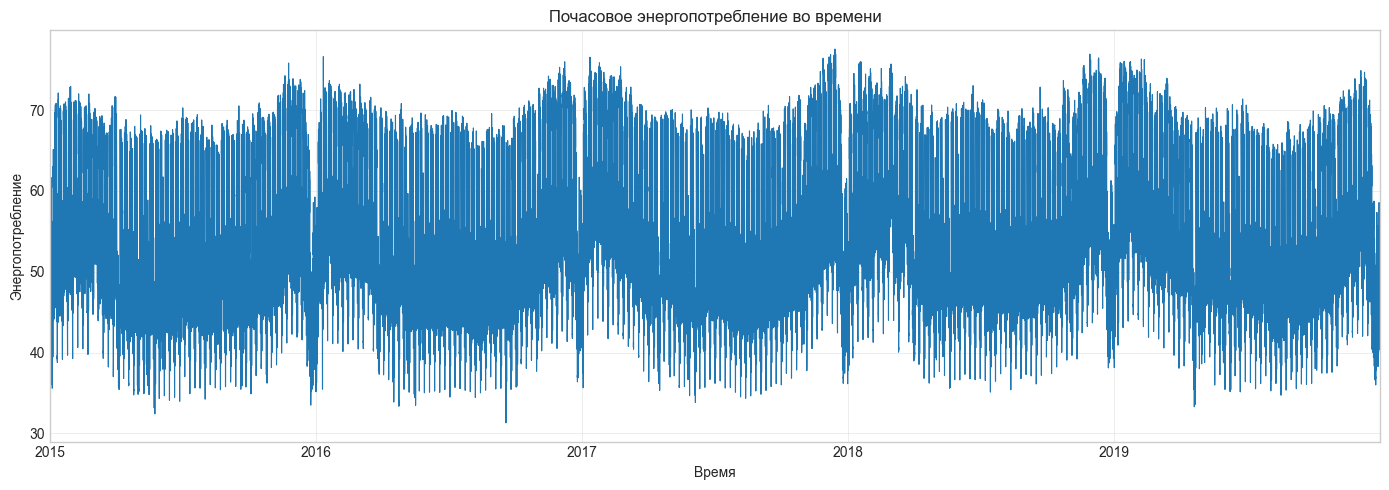

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
df[target_col].plot(ax=ax, color="tab:blue", linewidth=0.8)
ax.set_title("Почасовое энергопотребление во времени")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление")
plt.tight_layout()

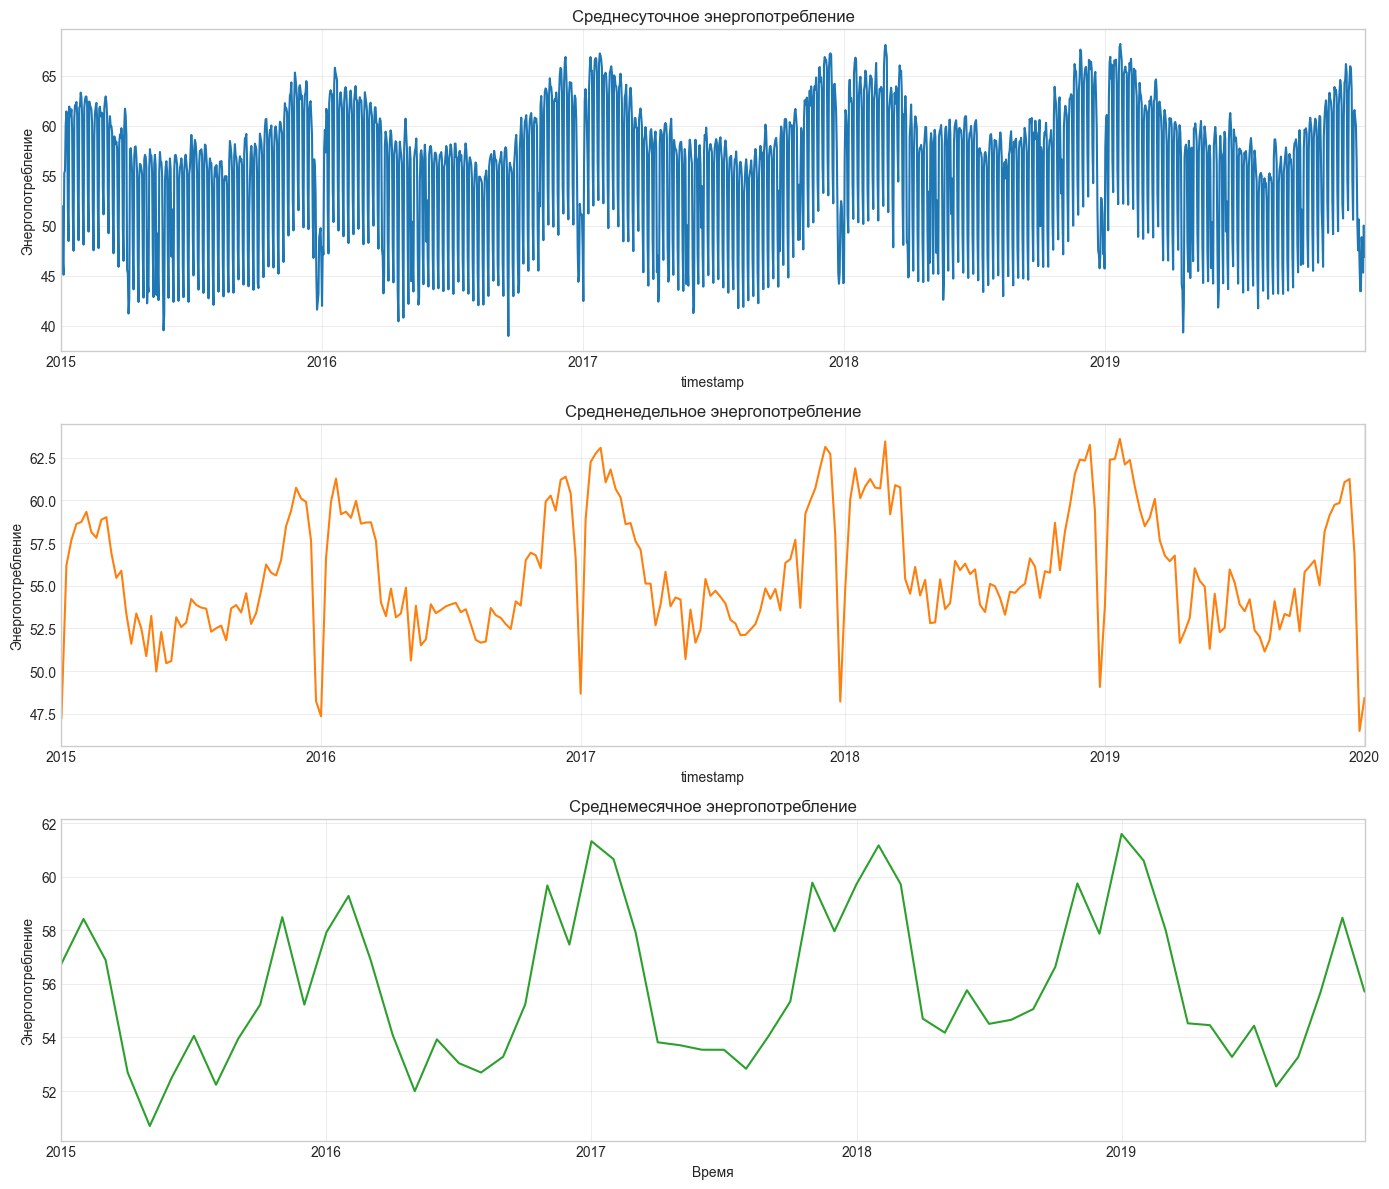

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

df[target_col].resample("D").mean().plot(ax=axes[0], color="tab:blue")
axes[0].set_title("Среднесуточное энергопотребление")
axes[0].set_ylabel("Энергопотребление")

df[target_col].resample("W").mean().plot(ax=axes[1], color="tab:orange")
axes[1].set_title("Средненедельное энергопотребление")
axes[1].set_ylabel("Энергопотребление")

df[target_col].resample("ME").mean().plot(ax=axes[2], color="tab:green")
axes[2].set_title("Среднемесячное энергопотребление")
axes[2].set_ylabel("Энергопотребление")
axes[2].set_xlabel("Время")

plt.tight_layout()

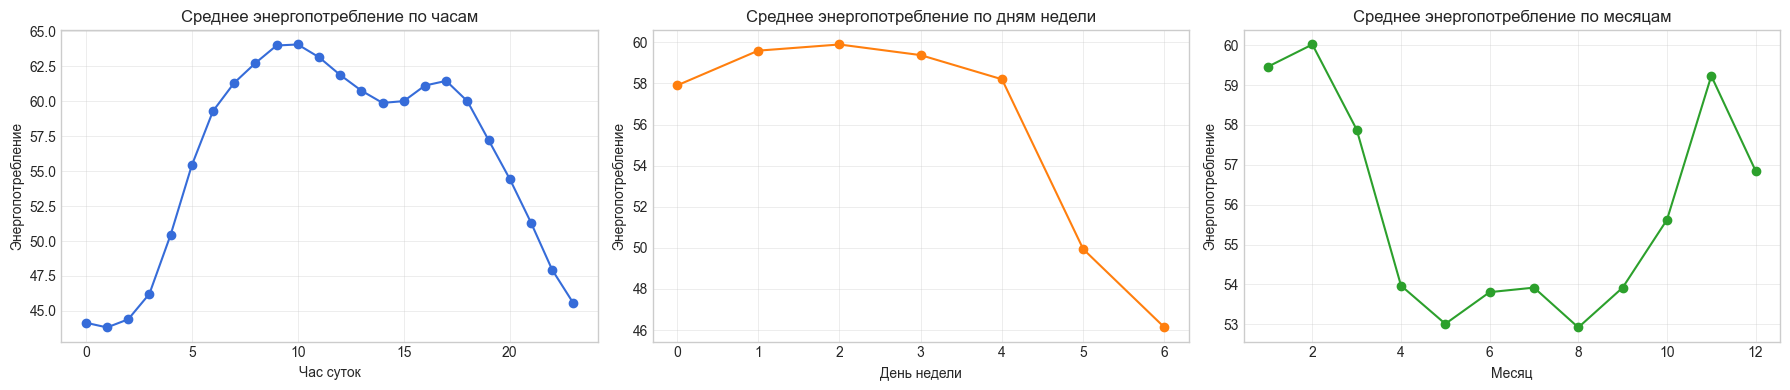

In [11]:
calendar_df = df.copy()
calendar_df["hour"] = calendar_df.index.hour
calendar_df["day_of_week"] = calendar_df.index.dayofweek
calendar_df["month"] = calendar_df.index.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

calendar_df.groupby("hour")[target_col].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Среднее энергопотребление по часам")
axes[0].set_xlabel("Час суток")
axes[0].set_ylabel("Энергопотребление")

calendar_df.groupby("day_of_week")[target_col].mean().plot(ax=axes[1], marker="o", color="tab:orange")
axes[1].set_title("Среднее энергопотребление по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Энергопотребление")

calendar_df.groupby("month")[target_col].mean().plot(ax=axes[2], marker="o", color="tab:green")
axes[2].set_title("Среднее энергопотребление по месяцам")
axes[2].set_xlabel("Месяц")
axes[2].set_ylabel("Энергопотребление")

plt.tight_layout()

По графикам целевой переменной проанализированы основные уровни сезонности: внутрисуточная, недельная и годовая. Эти паттерны используются далее при выборе лагов, календарных признаков и сезонных статистических моделей.

## Стационарность и структура ряда

Для статистических моделей важно оценить, насколько ряд похож на стационарный. В работе использованы скользящие статистики и формальные тесты на дневной агрегации, чтобы снизить шум почасовых колебаний.

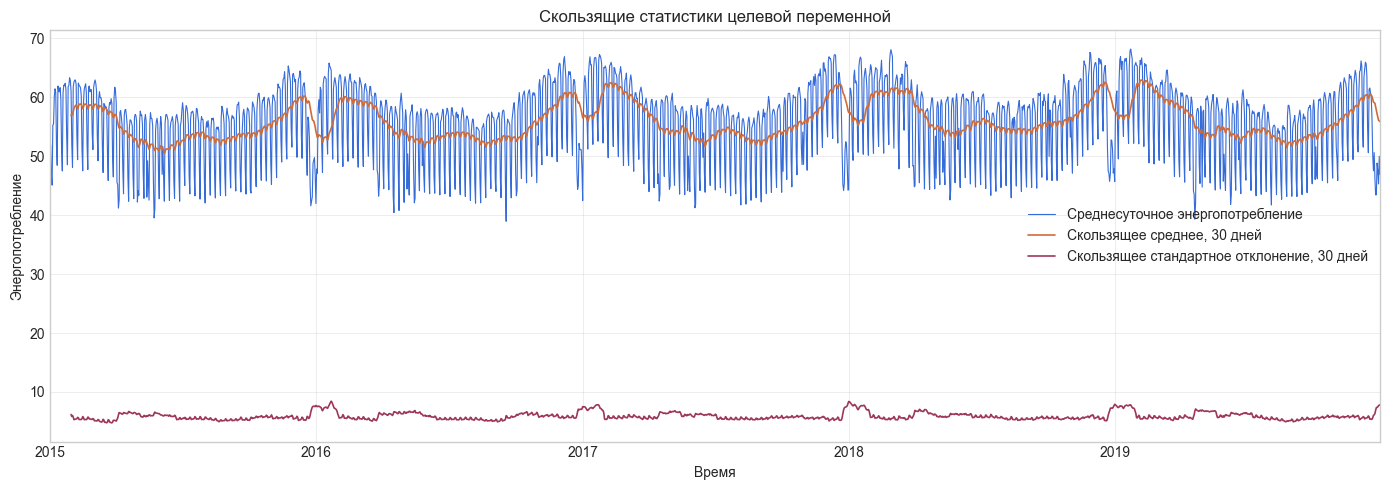

In [12]:
daily_target = df[target_col].resample("D").mean().dropna()
rolling_window = 30

rolling_mean = daily_target.rolling(rolling_window).mean()
rolling_std = daily_target.rolling(rolling_window).std()

fig, ax = plt.subplots(figsize=(14, 5))
daily_target.plot(ax=ax, label="Среднесуточное энергопотребление", linewidth=0.8)
rolling_mean.plot(ax=ax, label="Скользящее среднее, 30 дней", linewidth=1.2)
rolling_std.plot(ax=ax, label="Скользящее стандартное отклонение, 30 дней", linewidth=1.2)
ax.set_title("Скользящие статистики целевой переменной")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление")
ax.legend()
plt.tight_layout()

In [13]:
def stationarity_tests(series):
    series = series.dropna()
    adf_stat, adf_pvalue, _, _, adf_critical, _ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_pvalue, _, kpss_critical = kpss(series, regression="c", nlags="auto")

    return pd.DataFrame(
        {
            "test": ["ADF", "KPSS"],
            "statistic": [adf_stat, kpss_stat],
            "p_value": [adf_pvalue, kpss_pvalue],
            "null_hypothesis": [
                "ряд имеет единичный корень, нестационарен",
                "ряд стационарен вокруг константы",
            ],
            "critical_values": [adf_critical, kpss_critical],
        }
    )

stationarity_tests(daily_target)

C:\Users\PC\AppData\Local\Temp\ipykernel_15812\1292839118.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_critical = kpss(series, regression="c", nlags="auto")


,test,statistic,p_value,null_hypothesis,critical_values
0,ADF,-4.898502,0.000035,"ряд имеет единичный корень, нестационарен","{'1%': -3.4339800605797155, '5%': -2.863143469..."
1,KPSS,0.838754,0.010000,ряд стационарен вокруг константы,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."


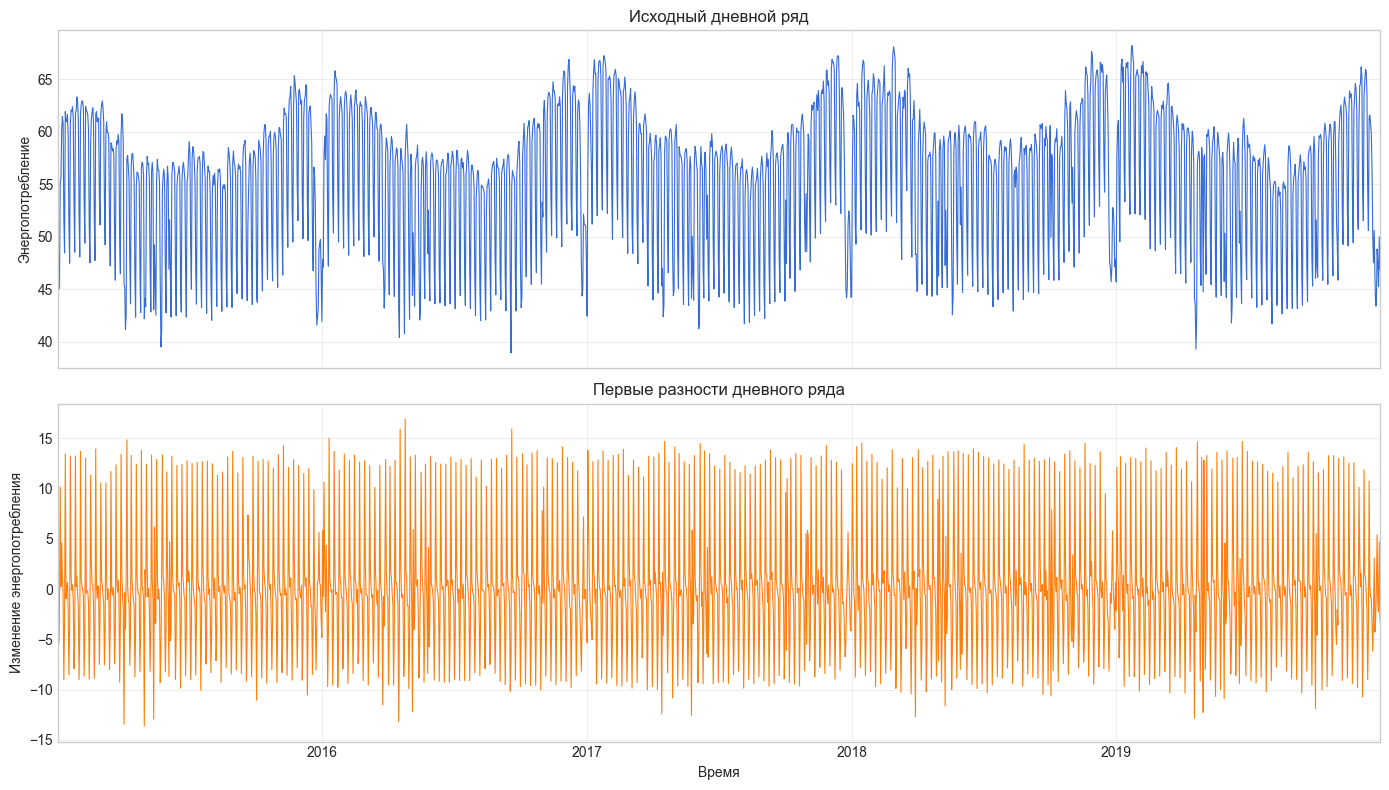

In [14]:
daily_diff = daily_target.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
daily_target.plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Исходный дневной ряд")
axes[0].set_ylabel("Энергопотребление")

daily_diff.plot(ax=axes[1], linewidth=0.8, color="tab:orange")
axes[1].set_title("Первые разности дневного ряда")
axes[1].set_xlabel("Время")
axes[1].set_ylabel("Изменение энергопотребления")

plt.tight_layout()

Тесты и скользящие статистики показывают, что ряд имеет выраженную сезонную структуру и не сводится к простому стационарному процессу. Для ARIMA-подобных моделей поэтому учитываются дифференцирование и сезонность. Для ML/DL-моделей это отражается через лаговые, календарные и rolling-признаки.

## Декомпозиция и автокорреляция

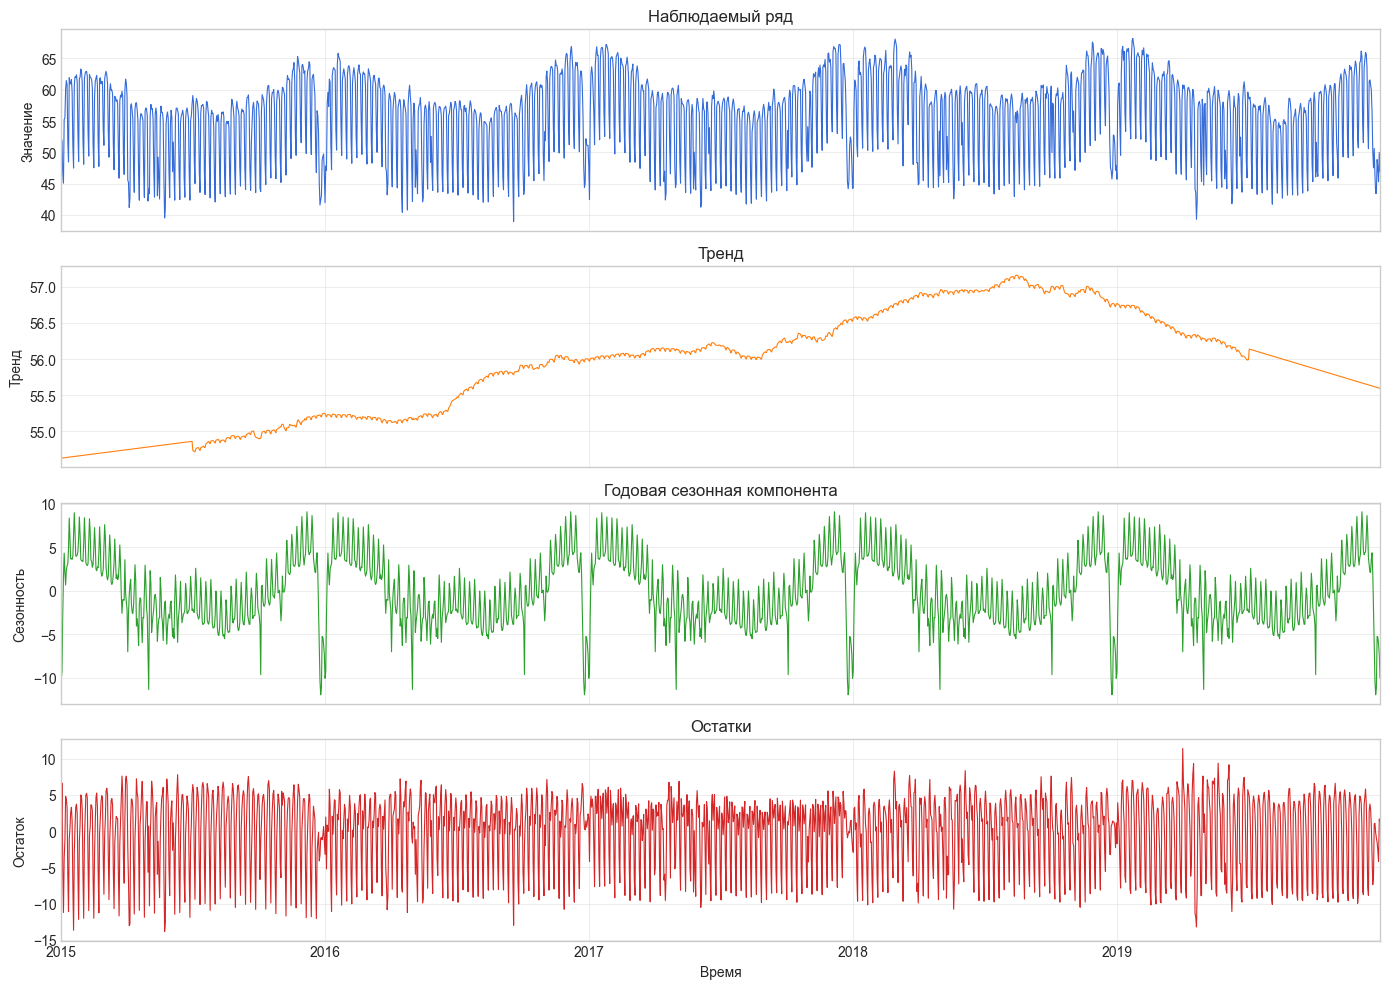

In [15]:
decomposition = seasonal_decompose(daily_target, model="additive", period=365, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Наблюдаемый ряд")
axes[0].set_ylabel("Значение")

decomposition.trend.plot(ax=axes[1], linewidth=0.8, color="tab:orange")
axes[1].set_title("Тренд")
axes[1].set_ylabel("Тренд")

decomposition.seasonal.plot(ax=axes[2], linewidth=0.8, color="tab:green")
axes[2].set_title("Годовая сезонная компонента")
axes[2].set_ylabel("Сезонность")

decomposition.resid.plot(ax=axes[3], linewidth=0.8, color="tab:red")
axes[3].set_title("Остатки")
axes[3].set_xlabel("Время")
axes[3].set_ylabel("Остаток")

plt.tight_layout()

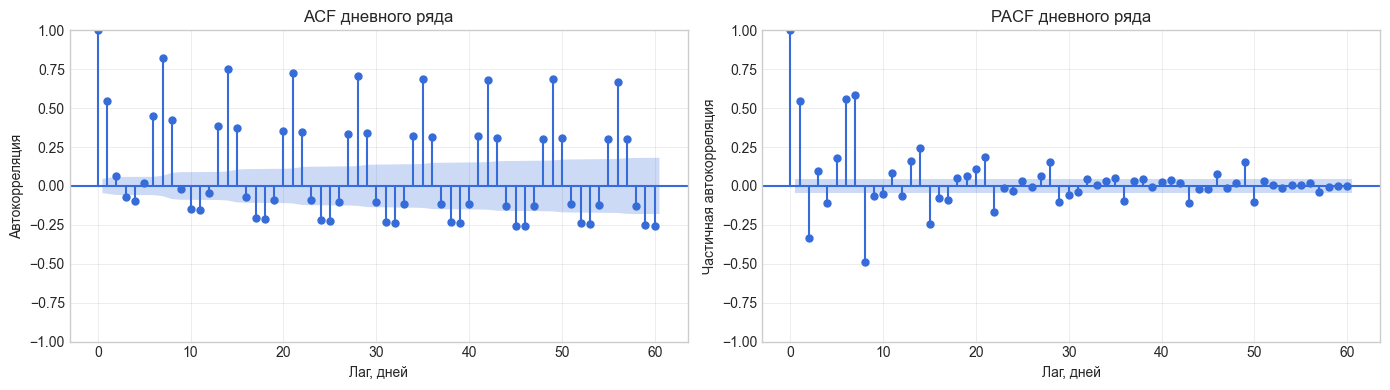

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily_target, lags=60, ax=axes[0])
axes[0].set_title("ACF дневного ряда")
axes[0].set_xlabel("Лаг, дней")
axes[0].set_ylabel("Автокорреляция")

plot_pacf(daily_target, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF дневного ряда")
axes[1].set_xlabel("Лаг, дней")
axes[1].set_ylabel("Частичная автокорреляция")

plt.tight_layout()

Декомпозиция и ACF/PACF использованы как связующий этап между EDA и моделированием. Они подтверждают наличие повторяющихся сезонных паттернов и помогают выбрать лаги для ML-моделей и сезонность для статистических моделей.

## Анализ погодных признаков

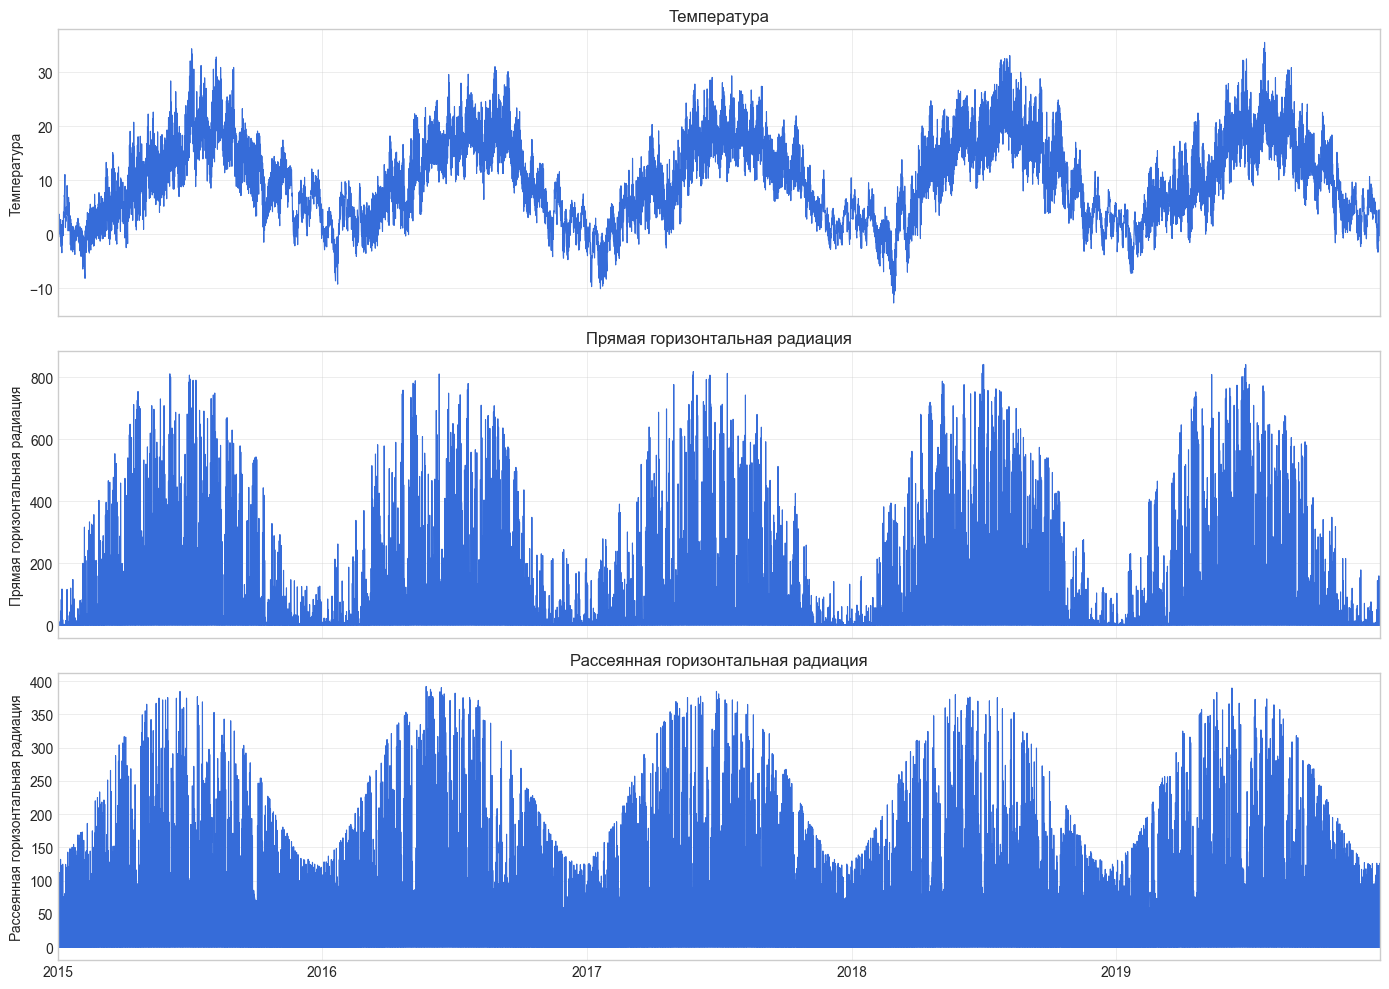

In [17]:
weather_feature_labels = {
    "temperature": "Температура",
    "radiation_direct_horizontal": "Прямая горизонтальная радиация",
    "radiation_diffuse_horizontal": "Рассеянная горизонтальная радиация",
}

fig, axes = plt.subplots(len(weather_features), 1, figsize=(14, 10), sharex=True)

for ax, feature in zip(axes, weather_features):
    df[feature].plot(ax=ax, linewidth=0.8)
    label = weather_feature_labels.get(feature, feature)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.tight_layout()

In [18]:
feature_cols = [target_col] + weather_features + energy_features
df[feature_cols].corr().round(3)

,Consumption,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,Wind,Solar,Wind+Solar
Consumption,1.000,-0.027,0.256,0.374,0.097,0.326,0.301
temperature,-0.027,1.000,0.528,0.474,-0.241,0.559,0.160
radiation_direct_horizontal,0.256,0.528,1.000,0.537,-0.192,0.928,0.448
radiation_diffuse_horizontal,0.374,0.474,0.537,1.000,-0.118,0.750,0.395
Wind,0.097,-0.241,-0.192,-0.118,1.000,-0.178,0.757
Solar,0.326,0.559,0.928,0.750,-0.178,1.000,0.508
Wind+Solar,0.301,0.160,0.448,0.395,0.757,0.508,1.000


Корреляционная матрица помогает первично оценить связь признаков с энергопотреблением, но не заменяет модельный отбор. Для временных рядов важны лаги, календарные признаки и возможные задержанные эффекты погоды.

## Сохранение подготовленных данных

In [19]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / "de_hourly_power_and_weather_prepared.csv"
df.to_csv(processed_path, index=True)

processed_path

WindowsPath('../data/processed/de_hourly_power_and_weather_prepared.csv')

## Итоги EDA

In [20]:
summary = {
    "n_rows": len(df),
    "n_features": df.shape[1],
    "start": df.index.min(),
    "end": df.index.max(),
    "frequency_check": df.index.to_series().diff().value_counts().head().to_dict(),
    "duplicate_timestamps": int(df.index.duplicated().sum()),
    "target": target_col,
    "forecast_horizon_hours": forecast_horizon,
    "train_period": (train_df.index.min(), train_df.index.max()),
    "test_period": (test_df.index.min(), test_df.index.max()),
    "target_missing": int(df[target_col].isna().sum()),
    "weather_missing": df[weather_features].isna().sum().to_dict(),
    "energy_missing": df[energy_features].isna().sum().to_dict(),
    "processed_path": str(processed_path),
}

summary_overview_df = pd.DataFrame([
    {"Показатель": "Количество строк", "Значение": summary["n_rows"]},
    {"Показатель": "Количество признаков", "Значение": summary["n_features"]},
    {"Показатель": "Начало периода", "Значение": summary["start"]},
    {"Показатель": "Конец периода", "Значение": summary["end"]},
    {"Показатель": "Дубликаты временных меток", "Значение": summary["duplicate_timestamps"]},
    {"Показатель": "Целевая переменная", "Значение": summary["target"]},
    {"Показатель": "Горизонт прогноза, часов", "Значение": summary["forecast_horizon_hours"]},
    {"Показатель": "Путь к prepared-файлу", "Значение": summary["processed_path"]},
])

periods_df = pd.DataFrame([
    {"Период": "Train", "Начало": summary["train_period"][0], "Конец": summary["train_period"][1]},
    {"Период": "Test", "Начало": summary["test_period"][0], "Конец": summary["test_period"][1]},
])

missing_rows = [{"Группа": "target", "Признак": target_col, "Пропуски": summary["target_missing"]}]
missing_rows += [{"Группа": "weather", "Признак": key, "Пропуски": value} for key, value in summary["weather_missing"].items()]
missing_rows += [{"Группа": "energy", "Признак": key, "Пропуски": value} for key, value in summary["energy_missing"].items()]
missing_df = pd.DataFrame(missing_rows)

frequency_df = (
    pd.Series(summary["frequency_check"], name="count")
    .reset_index()
    .rename(columns={"index": "interval"})
)

print("Общая сводка EDA")
display(summary_overview_df)
print("Train/test периоды")
display(periods_df)
print("Пропуски по ключевым признакам")
display(missing_df)
print("Наиболее частые интервалы временной шкалы")
display(frequency_df)

Общая сводка EDA


,Показатель,Значение
0,Количество строк,43824
1,Количество признаков,7
2,Начало периода,2015-01-01 00:00:00+00:00
3,Конец периода,2019-12-31 23:00:00+00:00
4,Дубликаты временных меток,0
5,Целевая переменная,Consumption
6,"Горизонт прогноза, часов",24
7,Путь к prepared-файлу,..\data\processed\de_hourly_power_and_weather_...


Train/test периоды


,Период,Начало,Конец
0,Train,2015-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00
1,Test,2019-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00


Пропуски по ключевым признакам


,Группа,Признак,Пропуски
0,target,Consumption,0
1,weather,temperature,0
2,weather,radiation_direct_horizontal,0
3,weather,radiation_diffuse_horizontal,0
4,energy,Wind,74
5,energy,Solar,103
6,energy,Wind+Solar,105


Наиболее частые интервалы временной шкалы


,interval,count
0,0 days 01:00:00,43823


Первый этап закрывает подготовку набора данных, постановку задачи, базовый EDA временного ряда, анализ сезонности и стационарности, а также сохранение подготовленных данных для следующих разделов работы.

## Интерпретация результатов

Данные представлены регулярным часовым временным рядом за период с 2015-01-01 по 2019-12-31. Временные метки отсортированы, дубликатов нет, основной шаг наблюдений составляет 1 час, поэтому ряд подходит для постановки задачи прогнозирования на горизонте 24 часа.

Целевая переменная `Consumption` не содержит пропусков и имеет выраженную суточную и недельную сезонность. Для последующих моделей важны лаги на 24 и 168 часов, календарные признаки и скользящие статистики. Погодные признаки используются как внешние факторы: солнечная радиация и генерация Solar/Wind+Solar связаны с потреблением, но окончательная полезность признаков проверяется уже на моделях.

По тестам стационарности и визуальному анализу ряд имеет устойчивую сезонную структуру. Поэтому простые сезонные baseline являются обязательной точкой сравнения для более сложных статистических и ML/DL-моделей.